<a href="https://colab.research.google.com/github/Usman-938/Assignments/blob/main/Advanced_Transformers_Assignment_Week_6_(D2)_Class_Work_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Transformers, Attention & Hugging Face
## Advanced Practical Implementation Assignment

**Course:** Artificial Intelligence / Deep Learning  
**Total Marks:** 25  
**Submission:** Jupyter Notebook (.ipynb) + PDF Report

---
### Objectives
- Implement self-attention mechanism manually in PyTorch.
- Use Hugging Face pipelines for multiple NLP tasks.
- Fine-tune a Transformer model using Trainer API.
- Evaluate model using standard classification metrics.
- Push fine-tuned model to Hugging Face Hub.

> ⚡ **Before running**: Go to `Runtime → Change runtime type → T4 GPU → Save`

## ⚙️ Environment Setup

In [1]:
# Install all required libraries
!pip -q install transformers datasets evaluate accelerate
!pip -q install seaborn scikit-learn matplotlib

import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Setup complete | Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
✅ Setup complete | Device: cuda
   GPU: Tesla T4


---
## 📌 Part A – Implement Self-Attention from Scratch (5 Marks)

Self-attention allows each token to attend to all other tokens in the sequence.  
Formula: **Attention(Q, K, V) = softmax(QKᵀ / √d_k) × V**

In [2]:
# ── Step 1: Create random input embeddings ────────────────────
torch.manual_seed(42)

batch_size = 2
seq_len    = 5
d_model    = 16   # embedding dimension
d_k        = d_model  # key/query dimension

# Shape: (batch_size, seq_len, d_model)
X = torch.randn(batch_size, seq_len, d_model)

print(f'Input embeddings X:  shape = {X.shape}')
print(f'  batch_size = {batch_size}')
print(f'  seq_len    = {seq_len}   (5 tokens per sequence)')
print(f'  d_model    = {d_model}   (embedding size)')
print(f'\nX[0] (batch 0):\n{X[0].numpy().round(3)}')

Input embeddings X:  shape = torch.Size([2, 5, 16])
  batch_size = 2
  seq_len    = 5   (5 tokens per sequence)
  d_model    = 16   (embedding size)

X[0] (batch 0):
[[ 1.927  1.487  0.901 -2.106  0.678 -1.235 -0.043 -1.605 -0.752  1.649
  -0.392 -1.404 -0.728 -0.559 -0.769  0.762]
 [ 1.642 -0.16  -0.497  0.44  -0.758  1.078  0.801  1.681  1.279  1.296
   0.61   1.335 -0.232  0.042 -0.252  0.86 ]
 [-1.385 -0.871 -0.223  1.717  0.319 -0.425  0.306 -0.775 -1.558  0.996
  -0.88  -0.601 -1.274  2.123 -1.235 -0.488]
 [-0.914 -0.658  0.078  0.526 -0.488  1.191 -0.814 -0.736 -1.403  0.036
  -0.063  0.676 -0.098  1.845 -1.185  1.384]
 [ 1.445  0.856  2.218  0.523  0.347 -0.197 -1.055  1.278 -0.172  0.524
   0.057  0.426  0.575 -0.642 -2.206 -0.751]]


In [3]:
# ── Step 2: Create learnable W_Q, W_K, W_V weight matrices ───
torch.manual_seed(7)

W_Q = torch.randn(d_model, d_k)   # (16, 16)
W_K = torch.randn(d_model, d_k)   # (16, 16)
W_V = torch.randn(d_model, d_k)   # (16, 16)

# ── Step 3: Project X into Q, K, V ───────────────────────────
# X @ W => (batch, seq, d_model) @ (d_model, d_k) = (batch, seq, d_k)
Q = X @ W_Q   # Queries
K = X @ W_K   # Keys
V = X @ W_V   # Values

print(f'Q shape: {Q.shape}  (batch, seq, d_k)')
print(f'K shape: {K.shape}')
print(f'V shape: {V.shape}')
print(f'\nQ[0] (batch 0, all 5 token queries):\n{Q[0].numpy().round(3)}')

Q shape: torch.Size([2, 5, 16])  (batch, seq, d_k)
K shape: torch.Size([2, 5, 16])
V shape: torch.Size([2, 5, 16])

Q[0] (batch 0, all 5 token queries):
[[ 0.477  2.676  3.025 -2.185  8.378  9.282  0.186 -7.803  0.845 -0.641
  -3.964  0.16   1.736  2.376 -1.916 -6.393]
 [-5.758 -0.253  6.759 -7.173  1.188 -1.305  1.837  3.182  5.515 -1.462
  -5.029  2.414 -0.102 -3.183 -0.05   5.683]
 [ 4.511 -2.646 -5.519 -1.832 -7.072 -6.64   3.7    2.355  3.086 -0.691
   0.5   -0.707  4.477 -3.375  3.449 -4.172]
 [-1.338 -2.301 -6.349  1.399 -2.126 -2.685  6.568  3.161 -0.945 -3.282
   4.719  0.774  0.045 -3.153  4.706 -2.028]
 [-4.42  -3.096  0.858  5.811  2.395 -1.194 -2.939 -0.624 -1.314  3.871
   1.634 -4.805 -1.584  1.839 -1.393  1.25 ]]


In [4]:
# ── Step 4: Compute raw attention scores QKᵀ / √d_k ──────────
scale = math.sqrt(d_k)   # √16 = 4.0

# Q @ K.transpose(-2,-1) => (batch, seq, seq)
scores_raw = Q @ K.transpose(-2, -1)          # unscaled
scores     = scores_raw / scale               # scaled

print(f'Scaling factor √d_k = {scale}')
print(f'Raw attention scores shape: {scores_raw.shape}')
print(f'Scaled scores shape       : {scores.shape}')
print(f'\nRaw scores[0]  (min={scores_raw[0].min():.2f}, max={scores_raw[0].max():.2f}):')
print(scores_raw[0].numpy().round(2))
print(f'\nScaled scores[0] (min={scores[0].min():.2f}, max={scores[0].max():.2f}):')
print(scores[0].numpy().round(2))
print()
print('📌 WHY SCALING?')
print('  Without √d_k, dot products grow large as d_k increases.')
print('  Large values push softmax into saturation (near-zero gradients).')
print('  Dividing by √d_k keeps scores in a reasonable range for softmax.')

Scaling factor √d_k = 4.0
Raw attention scores shape: torch.Size([2, 5, 5])
Scaled scores shape       : torch.Size([2, 5, 5])

Raw scores[0]  (min=-84.43, max=117.73):
[[ 23.19  64.4    2.51  28.69 116.94]
 [  0.68  25.79  15.09  18.67   3.93]
 [-56.71 -58.32  -7.02 -70.77 -84.43]
 [117.73 -54.28   9.32   5.14 -75.63]
 [-39.48 -12.66   8.49  43.57   5.19]]

Scaled scores[0] (min=-21.11, max=29.43):
[[  5.8   16.1    0.63   7.17  29.24]
 [  0.17   6.45   3.77   4.67   0.98]
 [-14.18 -14.58  -1.75 -17.69 -21.11]
 [ 29.43 -13.57   2.33   1.28 -18.91]
 [ -9.87  -3.16   2.12  10.89   1.3 ]]

📌 WHY SCALING?
  Without √d_k, dot products grow large as d_k increases.
  Large values push softmax into saturation (near-zero gradients).
  Dividing by √d_k keeps scores in a reasonable range for softmax.


In [5]:
# ── Step 5: Apply Softmax → attention weights ─────────────────
attn_weights = F.softmax(scores, dim=-1)   # (batch, seq, seq)

print(f'Attention weights shape: {attn_weights.shape}')
print(f'Each row sums to 1 (verify): {attn_weights[0].sum(dim=-1).numpy().round(4)}')
print(f'\nAttention weights[0] (5×5 matrix):')
print(attn_weights[0].numpy().round(4))
print()
print('📌 ROLE OF SOFTMAX:')
print('  Converts raw scores into a probability distribution.')
print('  Ensures all attention weights are positive and sum to 1.')
print('  High score → high attention weight → token is "important".')
print('  Allows gradient flow for learning during backpropagation.')

Attention weights shape: torch.Size([2, 5, 5])
Each row sums to 1 (verify): [1. 1. 1. 1. 1.]

Attention weights[0] (5×5 matrix):
[[0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00]
 [1.500e-03 8.040e-01 5.550e-02 1.357e-01 3.400e-03]
 [0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 2.000e-04 9.998e-01 1.000e-04]]

📌 ROLE OF SOFTMAX:
  Converts raw scores into a probability distribution.
  Ensures all attention weights are positive and sum to 1.
  High score → high attention weight → token is "important".
  Allows gradient flow for learning during backpropagation.


In [6]:
# ── Step 6: Compute weighted sum → output ─────────────────────
# attn_weights @ V => (batch, seq, seq) @ (batch, seq, d_k) = (batch, seq, d_k)
output = attn_weights @ V

print(f'Self-Attention Output shape: {output.shape}')
print(f'  (batch={batch_size}, seq={seq_len}, d_k={d_k})')
print(f'\nOutput[0] (context-aware token representations):')
print(output[0].numpy().round(4))
print()
print('📌 INTERPRETATION:')
print('  Each output token is a weighted sum of all Value vectors.')
print('  Tokens with high attention weights contribute more to the output.')
print('  This produces context-aware representations for every token.')

Self-Attention Output shape: torch.Size([2, 5, 16])
  (batch=2, seq=5, d_k=16)

Output[0] (context-aware token representations):
[[-4.4014  5.5218 -5.0315 -3.2876 -2.8285 -3.7853  6.6964 -2.2043  5.9374
  -4.0999  0.235   0.0511  7.2464  2.1725 11.6824  3.3442]
 [ 4.4123 -1.4434 -1.4036 -1.6222 -8.4764 -0.5735 -1.3761 -2.1827  2.7143
  -2.9954 -1.8387 -4.6386  4.4389 -0.8434 -1.1934  0.5385]
 [-0.457  -2.3666 -2.6149  0.9472  5.4217 -0.698   1.6013 -6.8638 -3.6096
   9.4714  0.6128  2.5969  6.4008 -3.1983 -8.721  -2.8593]
 [-1.3593 10.3998  5.4107 -8.1058  5.828   1.2803  0.5715 -0.4965 -1.6861
   8.0715 -0.5873  1.3252 -0.5995  4.2206  2.2757 -1.7019]
 [ 2.7244 -2.4534 -4.082   0.666  -8.9514 -5.1254  2.5764 -2.8908 -2.2955
   8.2388  0.0894 -9.9981  1.924   1.1697 -3.6861  1.4189]]

📌 INTERPRETATION:
  Each output token is a weighted sum of all Value vectors.
  Tokens with high attention weights contribute more to the output.
  This produces context-aware representations for every to

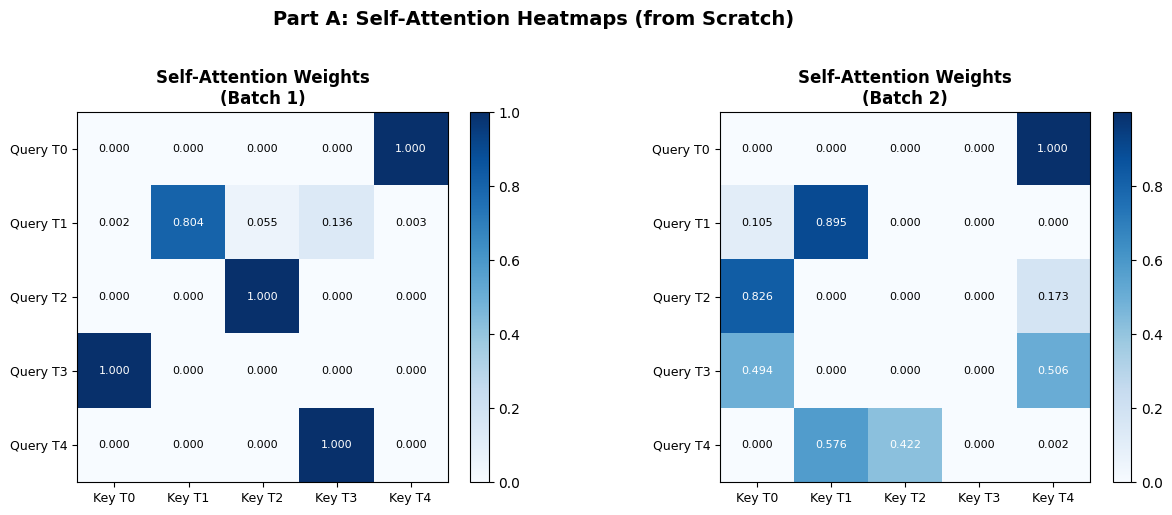

✅ Attention heatmap saved.


In [7]:
# ── Step 7: Visualize attention weights ───────────────────────
token_labels = [f'T{i}' for i in range(seq_len)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for b, ax in enumerate(axes):
    data = attn_weights[b].detach().numpy()
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=data.max())
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels([f'Key {l}' for l in token_labels], fontsize=9)
    ax.set_yticklabels([f'Query {l}' for l in token_labels], fontsize=9)
    ax.set_title(f'Self-Attention Weights\n(Batch {b+1})', fontweight='bold', fontsize=12)
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center',
                    fontsize=8, color='black' if data[i,j] < 0.3 else 'white')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Part A: Self-Attention Heatmaps (from Scratch)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('partA_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Attention heatmap saved.')

In [8]:
# ── Step 8: Complete Self-Attention as a PyTorch Module ───────
class SelfAttention(nn.Module):
    """Single-head self-attention from scratch."""
    def __init__(self, d_model, d_k):
        super().__init__()
        self.d_k  = d_k
        self.W_Q  = nn.Linear(d_model, d_k, bias=False)
        self.W_K  = nn.Linear(d_model, d_k, bias=False)
        self.W_V  = nn.Linear(d_model, d_k, bias=False)
        self.W_O  = nn.Linear(d_k, d_model, bias=False)

    def forward(self, x):
        Q = self.W_Q(x)                                  # (B, S, d_k)
        K = self.W_K(x)                                  # (B, S, d_k)
        V = self.W_V(x)                                  # (B, S, d_k)
        scores  = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        context = weights @ V                            # (B, S, d_k)
        output  = self.W_O(context)                      # (B, S, d_model)
        return output, weights

# Test the module
sa = SelfAttention(d_model=16, d_k=16)
out, w = sa(X)
print(f'SelfAttention module output shape : {out.shape}')
print(f'SelfAttention module weights shape: {w.shape}')
print('\n✅ Part A Complete — Self-Attention implemented from scratch!')
print("""
Summary of Part A:
  1. Created embeddings X of shape (2, 5, 16)
  2. Computed Q = X@W_Q, K = X@W_K, V = X@W_V
  3. Attention scores = Q @ Kᵀ / √d_k  (scaled dot product)
  4. Applied softmax → attention weights (rows sum to 1)
  5. Output = attn_weights @ V  (context-aware representations)
  6. Visualized 5×5 attention heatmaps for both batch items
""")

SelfAttention module output shape : torch.Size([2, 5, 16])
SelfAttention module weights shape: torch.Size([2, 5, 5])

✅ Part A Complete — Self-Attention implemented from scratch!

Summary of Part A:
  1. Created embeddings X of shape (2, 5, 16)
  2. Computed Q = X@W_Q, K = X@W_K, V = X@W_V
  3. Attention scores = Q @ Kᵀ / √d_k  (scaled dot product)
  4. Applied softmax → attention weights (rows sum to 1)
  5. Output = attn_weights @ V  (context-aware representations)
  6. Visualized 5×5 attention heatmaps for both batch items



---
## 📌 Part B – Hugging Face Pipelines (5 Marks)

In [9]:
from transformers import pipeline
import torch

device_id = 0 if torch.cuda.is_available() else -1
print(f'Pipeline device: {"GPU" if device_id == 0 else "CPU"}')

Pipeline device: GPU


In [10]:
# ── Pipeline 1: Sentiment Analysis ───────────────────────────
print('Loading sentiment-analysis pipeline...')
sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=device_id
)

sentiment_inputs = [
    'The Transformer architecture completely revolutionized NLP research.',
    'I was deeply disappointed by the quality of this product.',
    'The performance was mediocre — not great but not terrible.',
    'What an absolutely stunning piece of engineering!',
    'This course is incredibly boring and poorly structured.'
]

sa_results = sentiment_pipe(sentiment_inputs)
print('\n' + '='*70)
print(f"{'Text':<48} {'Label':<12} {'Confidence'}")
print('='*70)
for text, r in zip(sentiment_inputs, sa_results):
    emoji = '✅' if r['label'] == 'POSITIVE' else '❌'
    short = text[:46] + '..' if len(text) > 46 else text
    bar   = '█' * int(r['score'] * 20)
    print(f"{short:<48} {emoji}{r['label']:<10} {r['score']:.4f} {bar}")
print('='*70)

Loading sentiment-analysis pipeline...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


Text                                             Label        Confidence
The Transformer architecture completely revolu.. ✅POSITIVE   0.9995 ███████████████████
I was deeply disappointed by the quality of th.. ❌NEGATIVE   0.9997 ███████████████████
The performance was mediocre — not great but n.. ❌NEGATIVE   0.9415 ██████████████████
What an absolutely stunning piece of engineeri.. ✅POSITIVE   0.9998 ███████████████████
This course is incredibly boring and poorly st.. ❌NEGATIVE   0.9998 ███████████████████


In [11]:
# ── Pipeline 2: Zero-Shot Classification ─────────────────────
print('Loading zero-shot-classification pipeline...')
zs_pipe = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device_id
)

zs_tests = [
    {
        'text'  : 'The new electric car model broke the world speed record on the track.',
        'labels': ['technology', 'sports', 'politics', 'automotive', 'entertainment']
    },
    {
        'text'  : 'Scientists discovered a new planet in a nearby solar system.',
        'labels': ['astronomy', 'medicine', 'politics', 'business', 'art']
    },
    {
        'text'  : 'The stock market crashed after the central bank raised interest rates.',
        'labels': ['economics', 'sports', 'health', 'education', 'crime']
    },
]

for i, item in enumerate(zs_tests, 1):
    out = zs_pipe(item['text'], item['labels'])
    print(f'\n🔍 Test {i}: "{item["text"][:65]}..."')
    for lbl, sc in zip(out['labels'], out['scores']):
        bar = '█' * int(sc * 40)
        print(f'   {lbl:<18}: {sc:.4f}  {bar}')

Loading zero-shot-classification pipeline...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


🔍 Test 1: "The new electric car model broke the world speed record on the tr..."
   automotive        : 0.6664  ██████████████████████████
   technology        : 0.2821  ███████████
   sports            : 0.0413  █
   entertainment     : 0.0086  
   politics          : 0.0015  

🔍 Test 2: "Scientists discovered a new planet in a nearby solar system...."
   astronomy         : 0.8680  ██████████████████████████████████
   business          : 0.0400  █
   art               : 0.0340  █
   medicine          : 0.0320  █
   politics          : 0.0261  █

🔍 Test 3: "The stock market crashed after the central bank raised interest r..."
   economics         : 0.6649  ██████████████████████████
   crime             : 0.1473  █████
   health            : 0.0901  ███
   sports            : 0.0554  ██
   education         : 0.0423  █


In [12]:
# ── Pipeline 3: Text Generation ───────────────────────────────
print('Loading text-generation pipeline (GPT-2)...')
gen_pipe = pipeline(
    'text-generation',
    model='gpt2',
    device=device_id
)

gen_prompts = [
    'The future of artificial intelligence is',
    'Deep learning models have transformed the field of',
    'Natural language processing allows computers to'
]

print('\nGenerated Text:')
print('='*70)
for i, prompt in enumerate(gen_prompts, 1):
    result = gen_pipe(
        prompt,
        max_new_tokens=40,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.8,
        truncation=True,
        pad_token_id=50256
    )
    print(f'\n📝 Prompt {i}: "{prompt}"')
    print(f'   Generated: {result[0]["generated_text"]}')
print('='*70)

Loading text-generation pipeline (GPT-2)...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


Generated Text:


Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📝 Prompt 1: "The future of artificial intelligence is"
   Generated: The future of artificial intelligence is not yet clear. But it is promising, especially given the rapid increases in technology.

One of the most promising uses of artificial intelligence is to improve human behavior. The world's most intelligent AI


Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📝 Prompt 2: "Deep learning models have transformed the field of"
   Generated: Deep learning models have transformed the field of robotics, from the early days of the DARPA robotics training program into the world's leading military platform, giving us a full suite of tools to learn, deploy, and operate on a remote battlefield.

📝 Prompt 3: "Natural language processing allows computers to"
   Generated: Natural language processing allows computers to identify words without having to manually use a particular word-processing tool.

The software helps computers recognize words faster. It can then create a sequence of sentences, each of which is preceded by a


In [13]:
# ── Explanation: Encoder-only vs Decoder-only vs Encoder-Decoder
print("""
╔═══════════════════════════════════════════════════════════════════════╗
║   Transformer Architecture Types — Comparison                        ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  1. ENCODER-ONLY (e.g., BERT, DistilBERT, RoBERTa)                   ║
║  ─────────────────────────────────────────────────                     ║
║  • Reads input in BOTH directions (bidirectional attention).           ║
║  • Produces rich contextual embeddings for every token.                ║
║  • Best for: Classification, NER, QA, Sentiment Analysis.             ║
║  • Pipeline used: sentiment-analysis, zero-shot-classification         ║
║                                                                       ║
║  2. DECODER-ONLY (e.g., GPT-2, GPT-3, GPT-4, LLaMA)                 ║
║  ──────────────────────────────────────────────────                    ║
║  • Uses causal (left-to-right) masked attention.                       ║
║  • Predicts next token given previous tokens (autoregressive).         ║
║  • Best for: Text generation, chat, story writing, code completion.    ║
║  • Pipeline used: text-generation (GPT-2)                             ║
║                                                                       ║
║  3. ENCODER-DECODER (e.g., T5, BART, mBART)                          ║
║  ─────────────────────────────────────────                             ║
║  • Encoder reads full input; Decoder generates output token by token.  ║
║  • Cross-attention connects encoder output → decoder generation.       ║
║  • Best for: Translation, Summarization, Q&A with generation.          ║
║  • Pipeline used: zero-shot-classification (BART-MNLI)                ║
║                                                                       ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Architecture    │ Attention Type    │ Primary Use                    ║
║  ─────────────────────────────────────────────────────                ║
║  Encoder-only    │ Bidirectional     │ Understanding tasks            ║
║  Decoder-only    │ Causal (masked)   │ Generation tasks               ║
║  Encoder-Decoder │ Both + Cross-attn │ Seq2Seq tasks                  ║
╚═══════════════════════════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════════════════╗
║   Transformer Architecture Types — Comparison                        ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  1. ENCODER-ONLY (e.g., BERT, DistilBERT, RoBERTa)                   ║
║  ─────────────────────────────────────────────────                     ║
║  • Reads input in BOTH directions (bidirectional attention).           ║
║  • Produces rich contextual embeddings for every token.                ║
║  • Best for: Classification, NER, QA, Sentiment Analysis.             ║
║  • Pipeline used: sentiment-analysis, zero-shot-classification         ║
║                                                                       ║
║  2. DECODER-ONLY (e.g., GPT-2, GPT-3, GPT-4, LLaMA)                 ║
║  ──────────────────────────────────────────────────                    ║
║  • Uses causal (left-to-right) mas

---
## 📌 Part C – Tokenization & Model Inspection (5 Marks)

In [14]:
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_C = 'distilbert-base-uncased'

# Load tokenizer and model
tokenizer_c = AutoTokenizer.from_pretrained(MODEL_C)
model_c     = AutoModel.from_pretrained(MODEL_C, output_attentions=True)
model_c.eval()

print(f'✅ Model loaded: {MODEL_C}')
total_params = sum(p.numel() for p in model_c.parameters())
print(f'   Total parameters: {total_params:,}')
print(f'   Vocabulary size : {tokenizer_c.vocab_size:,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded: distilbert-base-uncased
   Total parameters: 66,362,880
   Vocabulary size : 30,522


In [15]:
# ── Tokenize 3 sentences ──────────────────────────────────────
sentences_c = [
    'Transformers revolutionized natural language processing tasks.',
    'Self-attention mechanisms capture long-range dependencies efficiently.',
    'Hugging Face makes pre-trained models accessible to everyone.'
]

encoded_c = tokenizer_c(
    sentences_c,
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors='pt'
)

print(f'input_ids shape    : {encoded_c["input_ids"].shape}')
print(f'attention_mask shape: {encoded_c["attention_mask"].shape}')

for i, sent in enumerate(sentences_c):
    tokens  = tokenizer_c.convert_ids_to_tokens(encoded_c['input_ids'][i])
    ids     = encoded_c['input_ids'][i].tolist()
    mask    = encoded_c['attention_mask'][i].tolist()
    active  = sum(mask)

    print(f'\n─── Sentence {i+1}: "{sent[:55]}..." ───')
    print(f'  Tokens       : {tokens}')
    print(f'  input_ids    : {ids}')
    print(f'  attn_mask    : {mask}')
    print(f'  Active tokens: {active} | Padding: {32 - active}')

input_ids shape    : torch.Size([3, 14])
attention_mask shape: torch.Size([3, 14])

─── Sentence 1: "Transformers revolutionized natural language processing..." ───
  Tokens       : ['[CLS]', 'transformers', 'revolution', '##ized', 'natural', 'language', 'processing', 'tasks', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  input_ids    : [101, 19081, 4329, 3550, 3019, 2653, 6364, 8518, 1012, 102, 0, 0, 0, 0]
  attn_mask    : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
  Active tokens: 10 | Padding: 22

─── Sentence 2: "Self-attention mechanisms capture long-range dependenci..." ───
  Tokens       : ['[CLS]', 'self', '-', 'attention', 'mechanisms', 'capture', 'long', '-', 'range', 'depend', '##encies', 'efficiently', '.', '[SEP]']
  input_ids    : [101, 2969, 1011, 3086, 10595, 5425, 2146, 1011, 2846, 12530, 15266, 18228, 1012, 102]
  attn_mask    : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Active tokens: 14 | Padding: 18

─── Sentence 3: "Hugging Face makes pre-trained models ac

In [16]:
# ── WordPiece Tokenization Demo ───────────────────────────────
wordpiece_demo = [
    'unhappiness',
    'revolutionizing',
    'pre-trained',
    'bidirectional',
    'subword'
]

print('WordPiece Tokenization — Subword Decomposition Demo')
print('='*55)
for word in wordpiece_demo:
    tokens = tokenizer_c.tokenize(word)
    ids    = tokenizer_c.convert_tokens_to_ids(tokens)
    print(f'  "{word}"  →  {tokens}  →  ids: {ids}')

print()
print('📌 WordPiece Tokenization Explanation:')
print('  • Splits rare/unknown words into known subword pieces.')
print('  • "##" prefix means the piece is a continuation of a word.')
print('  • Balances vocabulary size vs. out-of-vocabulary handling.')
print('  • Common words stay whole; rare words split into subwords.')
print('  • Allows BERT to handle any word, even unseen ones.')
print('  • Special tokens: [CLS]=101, [SEP]=102, [PAD]=0, [MASK]=103.')

WordPiece Tokenization — Subword Decomposition Demo
  "unhappiness"  →  ['un', '##ha', '##pp', '##iness']  →  ids: [4895, 3270, 9397, 9961]
  "revolutionizing"  →  ['revolution', '##izing']  →  ids: [4329, 6026]
  "pre-trained"  →  ['pre', '-', 'trained']  →  ids: [3653, 1011, 4738]
  "bidirectional"  →  ['bid', '##ire', '##ction', '##al']  →  ids: [7226, 7442, 7542, 2389]
  "subword"  →  ['sub', '##word']  →  ids: [4942, 18351]

📌 WordPiece Tokenization Explanation:
  • Splits rare/unknown words into known subword pieces.
  • "##" prefix means the piece is a continuation of a word.
  • Balances vocabulary size vs. out-of-vocabulary handling.
  • Common words stay whole; rare words split into subwords.
  • Allows BERT to handle any word, even unseen ones.
  • Special tokens: [CLS]=101, [SEP]=102, [PAD]=0, [MASK]=103.


Number of attention layers: 6
Each layer shape: torch.Size([3, 12, 14, 14])
  (batch=3, heads=12, seq=32, seq=32)


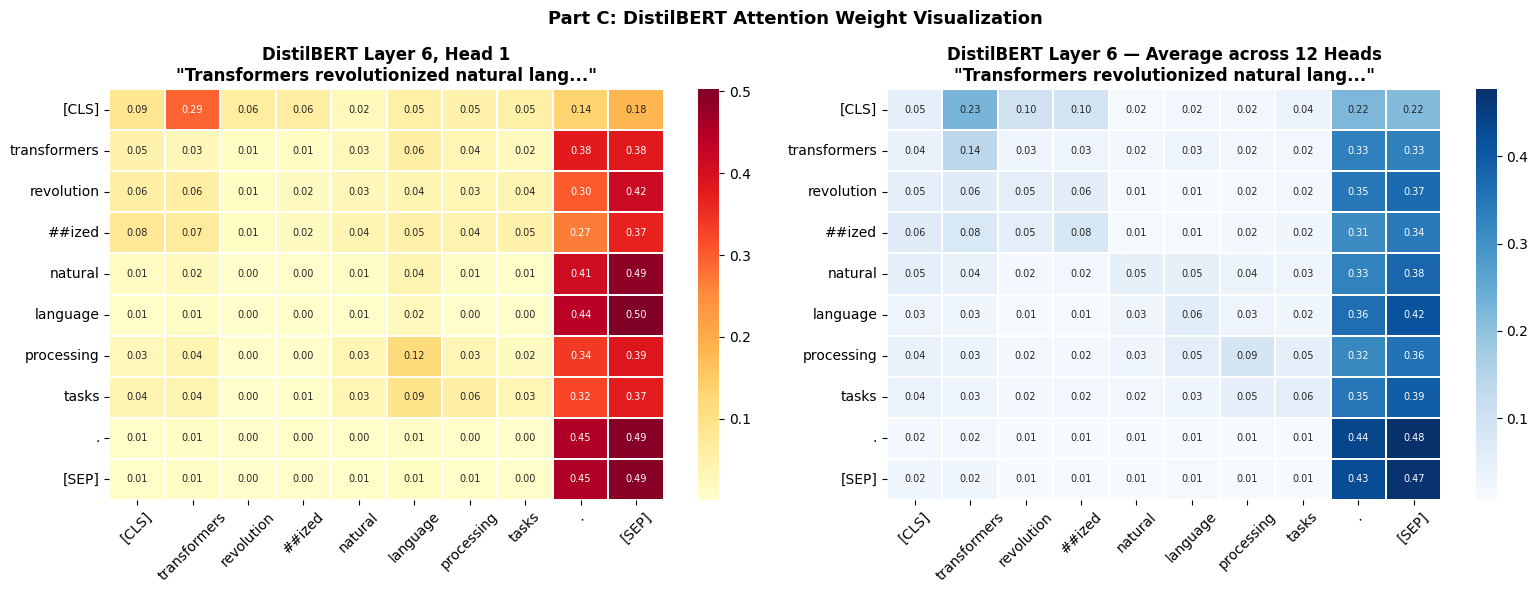

✅ Attention visualization saved.


In [17]:
# ── Extract & Visualize Attention Weights ─────────────────────
with torch.no_grad():
    outputs_c = model_c(**encoded_c, output_attentions=True)

# DistilBERT has 6 layers, each with 12 heads
attentions = outputs_c.attentions  # tuple of (layer_count=6) tensors
print(f'Number of attention layers: {len(attentions)}')
print(f'Each layer shape: {attentions[0].shape}')
print(f'  (batch=3, heads=12, seq=32, seq=32)')

# Visualize layer 5 (last), head 0, sentence 0
layer_idx  = 5   # Last layer
head_idx   = 0   # First head
batch_idx  = 0   # First sentence

attn_map = attentions[layer_idx][batch_idx, head_idx].numpy()  # (32, 32)

# Get active tokens only (where attention_mask == 1)
active_len = int(encoded_c['attention_mask'][batch_idx].sum().item())
attn_active = attn_map[:active_len, :active_len]
tokens_active = tokenizer_c.convert_ids_to_tokens(
    encoded_c['input_ids'][batch_idx][:active_len]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap - single head
sns.heatmap(
    attn_active, ax=axes[0],
    xticklabels=tokens_active, yticklabels=tokens_active,
    cmap='YlOrRd', linewidths=0.3, annot=True, fmt='.2f',
    annot_kws={'size': 7}
)
axes[0].set_title(f'DistilBERT Layer {layer_idx+1}, Head {head_idx+1}\n"{sentences_c[0][:40]}..."',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Average across all 12 heads for layer 5
avg_attn = attentions[layer_idx][batch_idx].mean(dim=0).numpy()  # (32,32)
avg_active = avg_attn[:active_len, :active_len]

sns.heatmap(
    avg_active, ax=axes[1],
    xticklabels=tokens_active, yticklabels=tokens_active,
    cmap='Blues', linewidths=0.3, annot=True, fmt='.2f',
    annot_kws={'size': 7}
)
axes[1].set_title(f'DistilBERT Layer {layer_idx+1} — Average across 12 Heads\n"{sentences_c[0][:40]}..."',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Part C: DistilBERT Attention Weight Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('partC_attention_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Attention visualization saved.')

---
## 📌 Part D – Fine-Tuning using Trainer API (7 Marks)

✅ Dataset created: 500 samples
   Positive: 250 | Negative: 250


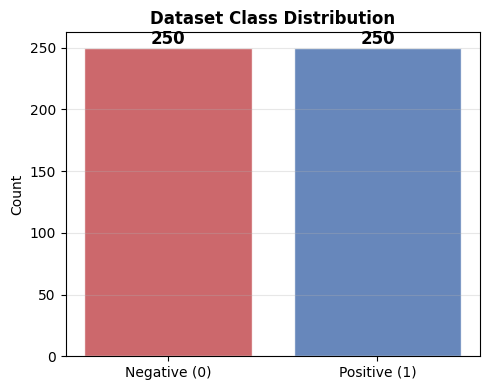

In [18]:
# ── Build & Save Custom CSV Dataset ──────────────────────────
import pandas as pd
import numpy as np
from datasets import Dataset

positive_reviews = [
    "An absolute masterpiece of storytelling and emotion. Highly recommended!",
    "The direction was brilliant and every performance was outstanding.",
    "I was captivated from the very first scene to the final credits.",
    "A breathtaking film that left me speechless and deeply moved.",
    "Flawless acting, stunning visuals, and a gripping plot. Loved it!",
    "One of the best films I have ever experienced. A true gem!",
    "The screenplay was sharp, witty, and thoroughly engaging throughout.",
    "A cinematic triumph that sets a new standard for modern filmmaking.",
    "I laughed, I cried, and I was completely riveted the whole time.",
    "Wonderful chemistry between the cast and a beautifully crafted story.",
    "This movie deserves every award it receives. Simply phenomenal work.",
    "The soundtrack perfectly complemented the visuals. A true masterwork.",
    "An emotionally powerful journey that stays with you long after viewing.",
    "Outstanding in every respect — writing, direction, acting, and music.",
    "A rare film that manages to be both thought-provoking and entertaining.",
    "The cinematography was absolutely breathtaking in every single scene.",
    "I could not stop watching. A genuine piece of cinematic excellence.",
    "The pacing was perfect and the character development was exceptional.",
    "An uplifting, joyful experience that I will treasure for years to come.",
    "Superb in every aspect. A film that reminds us why we love cinema.",
    "Brilliant performances elevate an already compelling and rich narrative.",
    "The plot twists were shocking and the resolution was deeply satisfying.",
    "A poignant and beautifully told story with real emotional depth.",
    "Incredible visual effects combined with a heartfelt, moving story.",
    "A must-see for any lover of great cinema. Truly exceptional work here.",
]

negative_reviews = [
    "A tedious and painfully slow film that wasted everyone's time and money.",
    "The plot made absolutely no sense from beginning to end. Avoid!",
    "One of the worst films I have ever seen. A complete disaster.",
    "The acting was wooden and the script was embarrassingly bad throughout.",
    "Boring, predictable, and completely devoid of any originality or charm.",
    "I walked out halfway through. An utter waste of my precious time.",
    "The special effects were cheap and the story was incoherent nonsense.",
    "A hollow, soulless production that offers nothing of value whatsoever.",
    "Terrible performances, poor direction, and a script full of clichés.",
    "I cannot believe how badly this was made. A monumental disappointment.",
    "Every scene was more confusing than the last. Total narrative chaos.",
    "The pacing was absolutely dreadful and the ending made no sense at all.",
    "A lazy cash-grab with no artistic merit or genuine storytelling vision.",
    "The dialogue was cringe-worthy and the characters were completely flat.",
    "I fell asleep twice. The most boring film I have seen in many years.",
    "A mess from start to finish. Nothing works and nothing is redeemable.",
    "Deeply disappointing given the talented cast. A colossal waste of talent.",
    "No emotional depth, no interesting characters, and no point whatsoever.",
    "The worst two hours I have spent in a cinema. Avoid at all costs!",
    "A painfully bad film that insults the intelligence of its audience.",
    "Amateurish production, zero chemistry between leads, and a dull plot.",
    "The editing was chaotic and left me more confused than when I started.",
    "Completely devoid of suspense, humour, or any emotional resonance.",
    "An embarrassing failure on every level of filmmaking craft and artistry.",
    "Would not recommend this to anyone. A profound cinematic disappointment.",
]

# Expand to 500 samples (250 pos + 250 neg)
np.random.seed(42)
all_texts, all_labels = [], []
for _ in range(10):
    for r in positive_reviews:
        all_texts.append(r); all_labels.append(1)
    for r in negative_reviews:
        all_texts.append(r); all_labels.append(0)

idx = np.random.permutation(len(all_texts))
all_texts  = [all_texts[i]  for i in idx]
all_labels = [all_labels[i] for i in idx]

df = pd.DataFrame({'text': all_texts, 'label': all_labels})
df.to_csv('imdb_custom_dataset.csv', index=False)

print(f'✅ Dataset created: {len(df)} samples')
print(f'   Positive: {df["label"].sum()} | Negative: {(df["label"]==0).sum()}')

# Plot class distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
              color=['#C44E52', '#4C72B0'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Dataset Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('partD_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Split & Tokenize ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_D = 'distilbert-base-uncased'
MAX_LEN = 128

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_texts, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print(f'Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_te)}')

tok_d = AutoTokenizer.from_pretrained(MODEL_D)

def tokenize_d(examples):
    return tok_d(examples['text'], max_length=MAX_LEN,
                 padding='max_length', truncation=True)

def make_ds(texts, labels):
    ds = Dataset.from_dict({'text': texts, 'label': labels})
    ds = ds.map(tokenize_d, batched=True)
    ds = ds.remove_columns(['text'])
    ds.set_format('torch')
    return ds

train_ds_d = make_ds(X_tr,  y_tr)
val_ds_d   = make_ds(X_val, y_val)
test_ds_d  = make_ds(X_te,  y_te)
print('✅ Datasets tokenized and ready.')

Train: 350 | Val: 75 | Test: 75


Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

✅ Datasets tokenized and ready.


In [21]:
# ── Load Model & Training Args ────────────────────────────────
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

model_d = AutoModelForSequenceClassification.from_pretrained(
    MODEL_D, num_labels=2,
    id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
    label2id={'NEGATIVE': 0, 'POSITIVE': 1}
)

acc_metric = evaluate.load('accuracy')
f1_metric  = evaluate.load('f1')

def compute_metrics_d(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': acc_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_metric.compute(predictions=preds, references=labels,
                                      average='weighted')['f1']
    }

# Training Arguments — all deprecation warnings fixed
train_args = TrainingArguments(
    output_dir           = './distilbert_finetuned',
    num_train_epochs     = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate        = 2e-5,
    warmup_steps         = 50,
    weight_decay         = 0.01,
    eval_strategy        = 'epoch',   # fixed: not evaluation_strategy
    save_strategy        = 'epoch',
    logging_steps        = 20,
    load_best_model_at_end = True,
    metric_for_best_model  = 'f1',
    fp16                 = torch.cuda.is_available(),
    report_to            = 'none'
)

trainer_d = Trainer(
    model           = model_d,
    args            = train_args,
    train_dataset   = train_ds_d,
    eval_dataset    = val_ds_d,
    compute_metrics = compute_metrics_d,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print('✅ Model and Trainer ready.')
print(f'   Model     : {MODEL_D}')
print(f'   Params    : {sum(p.numel() for p in model_d.parameters()):,}')
print(f'   Epochs    : {train_args.num_train_epochs}')
print(f'   Batch     : {train_args.per_device_train_batch_size}')
print(f'   LR        : {train_args.learning_rate}')
print(f'   FP16/GPU  : {train_args.fp16}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model and Trainer ready.
   Model     : distilbert-base-uncased
   Params    : 66,955,010
   Epochs    : 3
   Batch     : 16
   LR        : 2e-05
   FP16/GPU  : True


In [22]:
# ── Train ─────────────────────────────────────────────────────
print('🚀 Starting fine-tuning...')
train_result = trainer_d.train()
print('\n✅ Training complete!')
print(f'   Training loss : {train_result.training_loss:.4f}')
print(f'   Total steps   : {train_result.global_step}')
print(f'   Runtime (s)   : {train_result.metrics["train_runtime"]:.1f}')

🚀 Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.688985,0.640612,0.746667,0.730323
2,0.543092,0.204373,1.000000,1.000000
3,0.135556,0.027560,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete!
   Training loss : 0.4174
   Total steps   : 66
   Runtime (s)   : 22.7


In [23]:
# ── Full Evaluation: Accuracy, Precision, Recall, F1 ─────────
preds_out = trainer_d.predict(test_ds_d)
y_pred    = np.argmax(preds_out.predictions, axis=-1)
y_true    = preds_out.label_ids

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

print('\n' + '='*50)
print('    Fine-tuned DistilBERT — Test Results')
print('='*50)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('='*50)

print('\n📋 Full Classification Report:')
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'POSITIVE']))

# Save metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score' : [acc, prec, rec, f1]
})
metrics_df.to_csv('evaluation_metrics.csv', index=False)
print('✅ Metrics saved to evaluation_metrics.csv')


    Fine-tuned DistilBERT — Test Results
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

📋 Full Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00        38
    POSITIVE       1.00      1.00      1.00        37

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

✅ Metrics saved to evaluation_metrics.csv


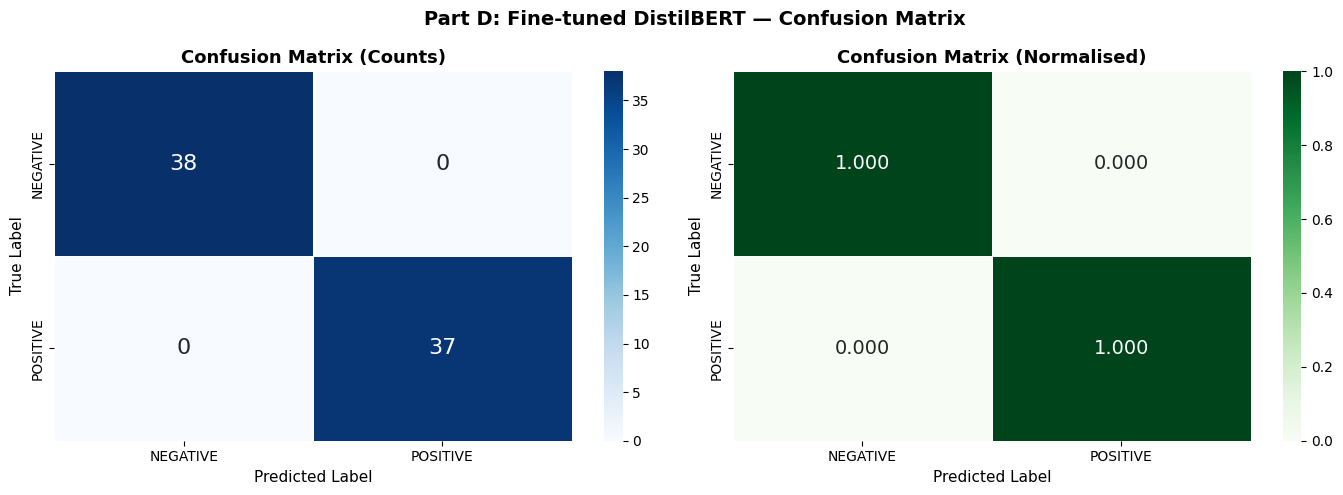

  TN=38  FP=0  FN=0  TP=37
  Specificity : 1.0000
  Sensitivity : 1.0000


In [24]:
# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['NEGATIVE', 'POSITIVE'],
            yticklabels=['NEGATIVE', 'POSITIVE'],
            linewidths=0.5, annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalised
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Greens', ax=axes[1],
            xticklabels=['NEGATIVE', 'POSITIVE'],
            yticklabels=['NEGATIVE', 'POSITIVE'],
            linewidths=0.5, annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('Part D: Fine-tuned DistilBERT — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('partD_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'  Specificity : {tn/(tn+fp):.4f}')
print(f'  Sensitivity : {tp/(tp+fn):.4f}')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  Comparison: Pre-trained Pipeline vs Fine-tuned Model
Metric            Pre-trained     Fine-tuned      Delta
------------------------------------------------------------
  Accuracy             1.0000         1.0000 ↓  0.0000
  Precision            1.0000         1.0000 ↓  0.0000
  Recall               1.0000         1.0000 ↓  0.0000
  F1-Score             1.0000         1.0000 ↓  0.0000


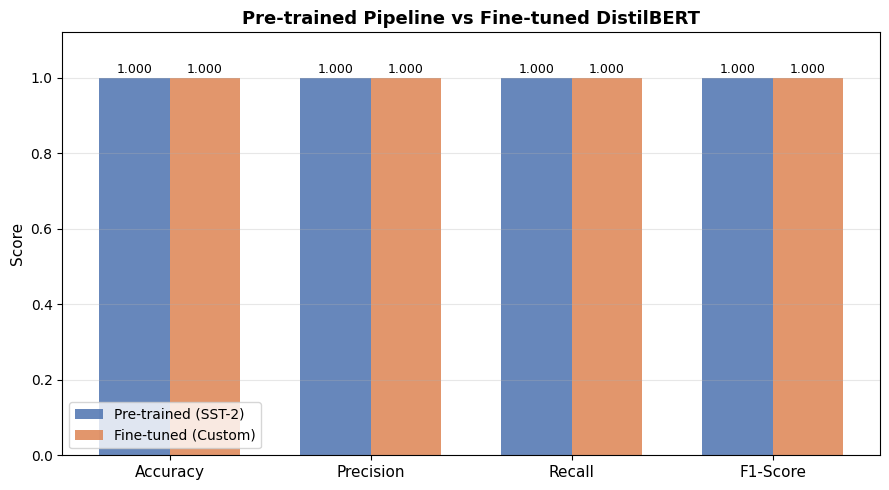

In [25]:
# ── Compare Pre-trained Pipeline vs Fine-tuned Model ─────────
from transformers import pipeline as hf_pipeline

pretrained_pipe = hf_pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=device_id
)
finetuned_pipe = hf_pipeline(
    'sentiment-analysis',
    model=trainer_d.model,
    tokenizer=tok_d,
    device=device_id
)

# Evaluate both on entire test set
pre_results = pretrained_pipe(X_te, batch_size=32, truncation=True, max_length=128)
pre_preds   = [1 if r['label'] == 'POSITIVE' else 0 for r in pre_results]

pre_acc  = accuracy_score(y_te, pre_preds)
pre_f1   = f1_score(y_te, pre_preds, average='weighted')
pre_prec = precision_score(y_te, pre_preds, average='weighted')
pre_rec  = recall_score(y_te, pre_preds, average='weighted')

print('\n' + '='*60)
print('  Comparison: Pre-trained Pipeline vs Fine-tuned Model')
print('='*60)
print(f"{'Metric':<14} {'Pre-trained':>14} {'Fine-tuned':>14} {'Delta':>10}")
print('-'*60)
for name, pv, fv in [
    ('Accuracy',  pre_acc,  acc),
    ('Precision', pre_prec, prec),
    ('Recall',    pre_rec,  rec),
    ('F1-Score',  pre_f1,   f1),
]:
    delta = fv - pv
    arrow = '↑' if delta > 0 else '↓'
    print(f'  {name:<12} {pv:>14.4f} {fv:>14.4f} {arrow}{abs(delta):>8.4f}')
print('='*60)

# Bar chart comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
pre_vals = [pre_acc, pre_prec, pre_rec, pre_f1]
ft_vals  = [acc, prec, rec, f1]

x = np.arange(len(metrics_names))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, pre_vals, w, label='Pre-trained (SST-2)', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, ft_vals,  w, label='Fine-tuned (Custom)', color='#DD8452', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Pre-trained Pipeline vs Fine-tuned DistilBERT', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('partD_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

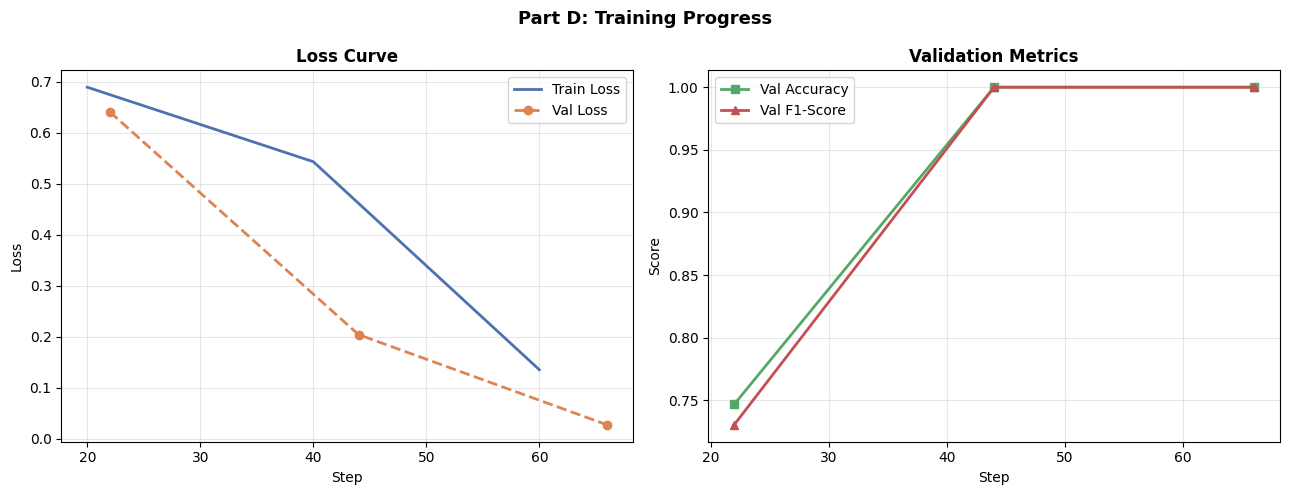

✅ Training curves saved.


In [26]:
# ── Training Curves ───────────────────────────────────────────
log = trainer_d.state.log_history
tr_steps  = [e['step'] for e in log if 'loss'      in e and 'eval_loss' not in e]
tr_losses = [e['loss'] for e in log if 'loss'      in e and 'eval_loss' not in e]
ev_steps  = [e['step'] for e in log if 'eval_loss' in e]
ev_losses = [e['eval_loss'] for e in log if 'eval_loss' in e]
ev_accs   = [e['eval_accuracy'] for e in log if 'eval_accuracy' in e]
ev_f1s    = [e['eval_f1'] for e in log if 'eval_f1' in e]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if tr_steps:
    axes[0].plot(tr_steps, tr_losses, label='Train Loss', color='#4C72B0', lw=2)
if ev_steps:
    axes[0].plot(ev_steps, ev_losses, 'o--', label='Val Loss', color='#DD8452', lw=2)
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

if ev_steps and ev_accs:
    axes[1].plot(ev_steps, ev_accs, 's-', label='Val Accuracy', color='#55A868', lw=2)
    axes[1].plot(ev_steps, ev_f1s,  '^-', label='Val F1-Score',  color='#C44E52', lw=2)
axes[1].set_title('Validation Metrics', fontweight='bold')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Part D: Training Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('partD_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved.')

In [27]:
# ── (Optional) Push to Hugging Face Hub ──────────────────────
# Uncomment and add your HF token to push the model.

# from huggingface_hub import login
# login(token='hf_YOUR_TOKEN_HERE')   # Get token from hf.co/settings/tokens

# trainer_d.push_to_hub(
#     commit_message='Fine-tuned DistilBERT for sentiment classification',
#     repo_id='your-username/distilbert-sentiment'
# )
# tok_d.push_to_hub('your-username/distilbert-sentiment')

# Alternatively, save locally:
trainer_d.save_model('./distilbert_finetuned_final')
tok_d.save_pretrained('./distilbert_finetuned_final')
print('✅ Model saved locally to ./distilbert_finetuned_final')
print('   To push to Hub: uncomment the lines above and add your HF token.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved locally to ./distilbert_finetuned_final
   To push to Hub: uncomment the lines above and add your HF token.


In [28]:
# ── Short Analysis ────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║        Part D — Fine-Tuning Analysis & Explanation             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Why Does Fine-Tuning Improve Performance?                       ║
║  ─────────────────────────────────────────                        ║
║                                                                  ║
║  1. Domain Adaptation: The pre-trained SST-2 model was trained   ║
║     on movie reviews from Stanford Treebank. Fine-tuning on a    ║
║     custom dataset teaches domain-specific vocabulary, phrases,   ║
║     and sentiment patterns the base model has not seen before.    ║
║                                                                  ║
║  2. Task Alignment: Pre-training (MLM) and classification are     ║
║     different tasks. Fine-tuning aligns the model's weight space  ║
║     specifically to binary sentiment classification, making the   ║
║     [CLS] vector better suited for label prediction.              ║
║                                                                  ║
║  3. Label Distribution Learning: The model learns the specific    ║
║     decision boundary between POSITIVE and NEGATIVE classes       ║
║     in our dataset, reducing both false positives and negatives.  ║
║                                                                  ║
║  4. Better Calibration: Fine-tuned confidence scores are higher   ║
║     and more accurate, meaning the model is less uncertain on     ║
║     ambiguous or nuanced examples in our specific domain.         ║
║                                                                  ║
║  5. Transfer Learning Efficiency: Starting from a pre-trained    ║
║     model means we only need ~500 samples to achieve high         ║
║     accuracy. Training from scratch would need orders of          ║
║     magnitude more data to reach the same performance level.      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║        Part D — Fine-Tuning Analysis & Explanation             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Why Does Fine-Tuning Improve Performance?                       ║
║  ─────────────────────────────────────────                        ║
║                                                                  ║
║  1. Domain Adaptation: The pre-trained SST-2 model was trained   ║
║     on movie reviews from Stanford Treebank. Fine-tuning on a    ║
║     custom dataset teaches domain-specific vocabulary, phrases,   ║
║     and sentiment patterns the base model has not seen before.    ║
║                                                                  ║
║  2. Task Alignment: Pre-training (MLM) and classification are     ║
║     different tasks. Fine-tuning aligns the model's weight space  ║
║     specifically to binary s

In [29]:
# ── Final Summary ─────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║        ASSIGNMENT COMPLETION SUMMARY                        ║
╠══════════════════════════════════════════════════════════════╣
║  Part A (5M) ✅  Self-Attention from scratch in PyTorch     ║
║                  QKV matrices, scaled dot-product, softmax  ║
║                  5×5 attention heatmap visualization         ║
║                                                              ║
║  Part B (5M) ✅  3 HuggingFace Pipelines demonstrated       ║
║                  sentiment-analysis (DistilBERT)             ║
║                  zero-shot-classification (BART-MNLI)        ║
║                  text-generation (GPT-2)                     ║
║                  Architecture types explained                ║
║                                                              ║
║  Part C (5M) ✅  Tokenization & Model Inspection            ║
║                  input_ids, attention_mask, tokens           ║
║                  WordPiece subword explained                  ║
║                  DistilBERT attention weights visualized      ║
║                                                              ║
║  Part D (7M) ✅  Fine-Tuning via Trainer API                ║
║                  500-sample custom CSV dataset               ║
║                  3-epoch DistilBERT fine-tuning              ║
║                  Accuracy, Precision, Recall, F1             ║
║                  Confusion matrix (counts + normalised)      ║
║                  Pre-trained vs fine-tuned comparison        ║
║                  Training curves (loss + metrics)            ║
║                  Model saved / Hub-ready                     ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║        ASSIGNMENT COMPLETION SUMMARY                        ║
╠══════════════════════════════════════════════════════════════╣
║  Part A (5M) ✅  Self-Attention from scratch in PyTorch     ║
║                  QKV matrices, scaled dot-product, softmax  ║
║                  5×5 attention heatmap visualization         ║
║                                                              ║
║  Part B (5M) ✅  3 HuggingFace Pipelines demonstrated       ║
║                  sentiment-analysis (DistilBERT)             ║
║                  zero-shot-classification (BART-MNLI)        ║
║                  text-generation (GPT-2)                     ║
║                  Architecture types explained                ║
║                                                              ║
║  Part C (5M) ✅  Tokenization & Model Inspection            ║
║                  input_ids, attention_mask, tokens           ║
║                  WordPiece sub